# Wstęp
Zadanie 7 stanowi wprowadzenie w tematykę transfer learning i wykorzystywania gotowych, publicznie udostępnianych modeli. W praktyce, dla zadań tak złożonych jak analiza obrazu, o wiele łatwiej jest dostosować istniejące już i wyuczone na dużych zbiorach danych modele do nowego zaadania, niż wyuczyć własny model od zera. Jako bardziej interesujący przykład zastosowania gotowych modeli zostanie pokazany też transfer stylu obrazów.

# Cel ćwiczenia

Celem ćwiczenia jest zapoznanie się z

*    mechanizmem importowania modeli
*    możliwościami wykorzystaniem transfer learningu do własnych zadań
*    transferem stylu jako przykładem wykorzystania cech z pretrenowanej architektury

# Importowanie modeli

Importowanie w torchu realizować będziemy poprzez ładowanie zapisanego obiektu słownika z wszystkimi parametrami warstw. Warto pamiętać tutaj, że słownik ten nie zapamiętuje pełnej struktury sieci, a jedynie parametry! Dlatego z jednej strony dla wczytania gotowego modelu konieczne jest istnienie odpowiedniej architektury w kodzie (zaimplementowany `torch.nn.Module` realizujący tę architekturę). Z drugiej zaś, słownik parametrów zgodny pod względem nazw i kształtów parametrów z zadaną architekturą możemy wczytać do dowolnej, dostosowanej do naszych potrzeb klasy - w szczególności umożliwiając nam własną implementację `forward`. Na razie sprawdźmy model, który ma już swoją implementację w `torchvision`: klasyczną architekturę VGG.

In [1]:
import torch
import torchvision.models as models
from matplotlib import pyplot as plt
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


vgg19 = models.vgg19(pretrained=True)

print(vgg19)

Using device: cuda


/home/mikol/ai_studies/Deep-Neural-Networks-PWR/.venv/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/mikol/ai_studies/Deep-Neural-Networks-PWR/.venv/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG19_Weights.IMAGENET1K_V1`. You can also use `weights=VGG19_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padd

W kontekście vgg19, interesuje nas szczególnie moduł features: instancja `torch.nn.Sequential', obejmująca konwolucyjną część architektury. Dla nowych zadań analizy obrazów, możemy wykorzystać tę częśc z własnym klassyfikatorem.

In [2]:
print(vgg19.features)

Sequential(
  (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU(inplace=True)
  (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (3): ReLU(inplace=True)
  (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (6): ReLU(inplace=True)
  (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (8): ReLU(inplace=True)
  (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (11): ReLU(inplace=True)
  (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (13): ReLU(inplace=True)
  (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (15): ReLU(inplace=True)
  (16): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (17): ReLU(inplace=True)
  (18): MaxPoo

Tutaj warto zwrócić jeszcze uwagę na przydatną własność `torch.nn.Sequential`: ta klasa jest indeksowalna, a kiedy korzystamy z indeksowania aby zwócić ciąg następujących po sobie elementów, zwracana jest również instancja `torch.nn.Sequential`:

In [3]:
print(f"pod indeksem 3 jest: {vgg19.features[3]}")
print(f"pod indeksami 3 do 7 jest: {vgg19.features[3:7]}")

pod indeksem 3 jest: ReLU(inplace=True)
pod indeksami 3 do 7 jest: Sequential(
  (3): ReLU(inplace=True)
  (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (6): ReLU(inplace=True)
)


# Zadanie 1

Zdefiniuj klasę LabVGG19, która inicjalizuje swoje parametry poprzez wczytanie wyuczonego modelu z torchvision.models, ale jej `forward` zwraca na wyjściu krotkę lub listę `out` gdzie



*   `out[0]` - cechy z poziomu architektury poprzedzającego pierwszy Max Pooling
*    `out[1]` - cechy z poziomu architektury poprzedzającego drugi Max Pooling
*    `out[2]` - cechy z poziomu architektury poprzedzającego trzeci Max Pooling


In [4]:
class LabVGG19(torch.nn.Module):
    def __init__(self):
        super().__init__()
        vgg19 = models.vgg19(pretrained=True)
        
        self.block1 = vgg19.features[0:4]
        self.block2 = vgg19.features[4:9]
        self.block3 = vgg19.features[9:18]
        
        for param in self.parameters():
            param.requires_grad = False

    def forward(self, x):
        out0 = self.block1(x) 
        out1 = self.block2(out0)
        out2 = self.block3(out1)
        return [out0, out1, out2]

Zweryfikuj działanie architektury

In [5]:
model = LabVGG19()
dummy_input = torch.zeros((3,3,32,32))
out = model(dummy_input)

assert(out[0].shape == (3,64,32,32))
assert(out[1].shape == (3,128,16,16))
assert(out[2].shape == (3,256,8,8))

# Transfer Learning

Mając możliwość wydobywania cech z dowolnego poziomu architektury, możemy łatwo wykorzystać je do dowolnych nowych zadań. Wystarczy zbudować model, który przetwarza jako wejście to, co wynika z naszego wcześniejszego przetwarzania przez wyuczoną już sieć. Zaimportowaną część sieci możemy zarówno **douczać** jak i **zamrozić** w zależności od tego czy jej parametry podamy przy naszym uczeniu do optymalizowania. W tym drugim przypadku, warto pamiętać o wyłączeniu gradientów dla zamrożonych warstw.

Poniżej kod pomocniczy z laboratorium 3, można zastąpić go własną implementacją pętli uczącej uwzględniającej ulepszenia wykonane na laboratoriach 4 i 5. W zadaniach poniżej wystarczy porównać końcowy wynik uczenia, nie jest wymagane wyrysowywanie pełnych krzywych w tensorboard niemniej mogą one pomóc w analizie otrzymanych wyników.


**VGG na wejściu oczekuje danych znormalizowanych, z określonymi wartościami średniej i odchylenia standardowego. Transformacja wejściowa powinna korzystać z `transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))`.**

In [ ]:
import torchvision
import torchvision.transforms as transforms
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from typing import Tuple
from tqdm import tqdm
import mlflow


transform = transforms.Compose([transforms.ToTensor(),
                                    transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))])

train_ds = torchvision.datasets.CIFAR10("cifar_root", transform=transform, download=True)
test_ds = torchvision.datasets.CIFAR10("cifar_root", transform=transform, train=False, download=True)

train_dl = DataLoader(train_ds, batch_size=32, shuffle=True, pin_memory=True)
test_dl = DataLoader(test_ds, batch_size=32, pin_memory=True)

def count_correct(
    y_pred: torch.Tensor, y_true: torch.Tensor
) -> torch.Tensor:
    preds = torch.argmax(y_pred, dim=1)
    return (preds == y_true).float().sum()

def validate(
    model: nn.Module,
    loss_fn: torch.nn.CrossEntropyLoss,
    dataloader: DataLoader
) -> Tuple[torch.Tensor, torch.Tensor]:
    loss = 0
    correct = 0
    all = 0
    for X_batch, y_batch in dataloader:
        y_pred = model(X_batch.to(device))
        all += len(y_pred)
        loss += loss_fn(y_pred, y_batch.to(device)).sum()
        correct += count_correct(y_pred, y_batch.to(device))
    return loss / all, correct / all

def fit(
    model: nn.Module, optimiser: optim.Optimizer,
    loss_fn: torch.nn.CrossEntropyLoss, train_dl: DataLoader,
    val_dl: DataLoader, epochs: int,
    print_metrics: bool = True,
    run_name: str = None,
    params: dict = None
):
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

    with mlflow.start_run(run_name=run_name):

        if params:
            mlflow.log_params(params)

        for epoch in range(epochs):
            model.train()
            for X_batch, y_batch in tqdm(train_dl, desc=f"Epoch {epoch}"):
                y_pred = model(X_batch.to(device))
                loss = loss_fn(y_pred, y_batch.to(device))
                loss.backward()
                optimiser.step()
                optimiser.zero_grad()

            model.eval()
            with torch.no_grad():
                train_loss, train_acc = validate(model=model, loss_fn=loss_fn, dataloader=train_dl)
                val_loss, val_acc     = validate(model=model, loss_fn=loss_fn, dataloader=val_dl)

            history["train_loss"].append(train_loss.item())
            history["train_acc"].append(train_acc.item())
            history["val_loss"].append(val_loss.item())
            history["val_acc"].append(val_acc.item())

            mlflow.log_metrics({
                "train_loss": train_loss.item(),
                "train_acc":  train_acc.item(),
                "val_loss":   val_loss.item(),
                "val_acc":    val_acc.item(),
            }, step=epoch)

            if print_metrics:
                print(
                    f"Epoch {epoch}: "
                    f"train loss = {train_loss:.3f} (acc: {train_acc:.3f}), "
                    f"val loss = {val_loss:.3f} (acc: {val_acc:.3f})"
                )

    return history



def plot_history(history: dict):
    epochs = range(len(history["train_loss"]))

    # --- Tabelka ---
    print(f"{'Epoka':<8} {'Train Loss':<12} {'Train Acc':<12} {'Val Loss':<12} {'Val Acc':<12}")
    print("-" * 56)
    for i in epochs:
        print(
            f"{i:<8} "
            f"{history['train_loss'][i]:<12.4f} "
            f"{history['train_acc'][i]:<12.4f} "
            f"{history['val_loss'][i]:<12.4f} "
            f"{history['val_acc'][i]:<12.4f}"
        )
    print("-" * 56)
    print(
        f"{'BEST':<8} "
        f"{'':12} "
        f"{max(history['train_acc']):<12.4f} "
        f"{'':12} "
        f"{max(history['val_acc']):<12.4f}"
    )

    # --- Wykresy ---
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.plot(epochs, history["train_loss"], label="train")
    ax1.plot(epochs, history["val_loss"],   label="val")
    ax1.set_title("Loss")
    ax1.set_xlabel("Epoka")
    ax1.set_ylabel("Loss")
    ax1.legend()
    ax1.grid(True)

    ax2.plot(epochs, history["train_acc"], label="train")
    ax2.plot(epochs, history["val_acc"],   label="val")
    ax2.set_title("Accuracy")
    ax2.set_xlabel("Epoka")
    ax2.set_ylabel("Accuracy")
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    plt.show()


mlflow.set_tracking_uri("http://localhost:5002")
mlflow.set_experiment("lab7_deep_neural_networks")

Files already downloaded and verified
Files already downloaded and verified


<Experiment: artifact_location='/mlflow/artifacts/1', creation_time=1776793573924, experiment_id='1', last_update_time=1776793573924, lifecycle_stage='active', name='lab7_deep_neural_networks', tags={}, trace_location=None, workspace='default'>

# Zadanie 2

Zaimplementuj model korzystający z cech wyjściowych na pierwszym, drugim i trzecim poziomie zwracanym przez LabVGG19. (Wykorzystaj Adaptive Pooling aby uniknąć gigantycznej wymiarowości wynikającej ze spłaszczania na tych poziomach). Porównaj wyniki tego modelu na CIFAR10 w wariantach: zamrożonych warstw konwolucyjnych i z douczaniem warstw konwolucyjnych.

Uwaga: zadania 2 i 3 będą wymagały więcej czasu przetwarzania niż wysiłku intelektualnego, więc polecane jest wykonanie ich jako ostatnich, a na zajęciach - przejście do punktu Transfer Stylu.

=== WARIANT 1: Zamrożony ===


/home/mikol/ai_studies/Deep-Neural-Networks-PWR/.venv/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/mikol/ai_studies/Deep-Neural-Networks-PWR/.venv/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG19_Weights.IMAGENET1K_V1`. You can also use `weights=VGG19_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Epoch 0:   0%|          | 0/1563 [00:00<?, ?it/s]/home/mikol/ai_studies/Deep-Neural-Networks-PWR/.venv/lib/python3.11/site-packages/torch/nn/modules/conv.py:459: UserWarning: Applied workaround for CuDNN issue, install nvrtc.so (Triggered internally at ../aten/src/ATen/native/cudnn/Conv_v8.cpp:80

Epoch 0: train loss = 0.022 (acc: 0.754), val loss = 0.023 (acc: 0.744)


Epoch 1: 100%|██████████| 1563/1563 [00:28<00:00, 55.59it/s]


Epoch 1: train loss = 0.018 (acc: 0.806), val loss = 0.020 (acc: 0.785)


...

Epoch 27: train loss = 0.009 (acc: 0.896), val loss = 0.017 (acc: 0.830)


Epoch 28: 100%|██████████| 1563/1563 [00:26<00:00, 58.54it/s]


Epoch 28: train loss = 0.009 (acc: 0.900), val loss = 0.016 (acc: 0.834)


Epoch 29: 100%|██████████| 1563/1563 [00:26<00:00, 58.06it/s]


Epoch 29: train loss = 0.009 (acc: 0.901), val loss = 0.017 (acc: 0.831)
🏃 View run frozen at: http://localhost:5002/#/experiments/1/runs/65f6a57405a24fff8805aac0883ce7e2
🧪 View experiment at: http://localhost:5002/#/experiments/1
Epoka    Train Loss   Train Acc    Val Loss     Val Acc     
--------------------------------------------------------
0        0.0221       0.7540       0.0232       0.7437      
1        0.0180       0.8059       0.0198       0.7845      
2        0.0170       0.8133       0.0191       0.7940      
3        0.0169       0.8183       0.0192       0.7930      
4        0.0142       0.8410       0.0171       0.8158      
5        0.0146       0.8379       0.0177       0.8047      
6        0.0137       0.8465       0.0173       0.8174      
7        0.0135       0.8477       0.0174       0.8141      
8        0.0137       0.8459       0.0178       0.8088      
9        0.0130       0.8578       0.0171       0.8132      
10       0.0128       0.8588       0.0173

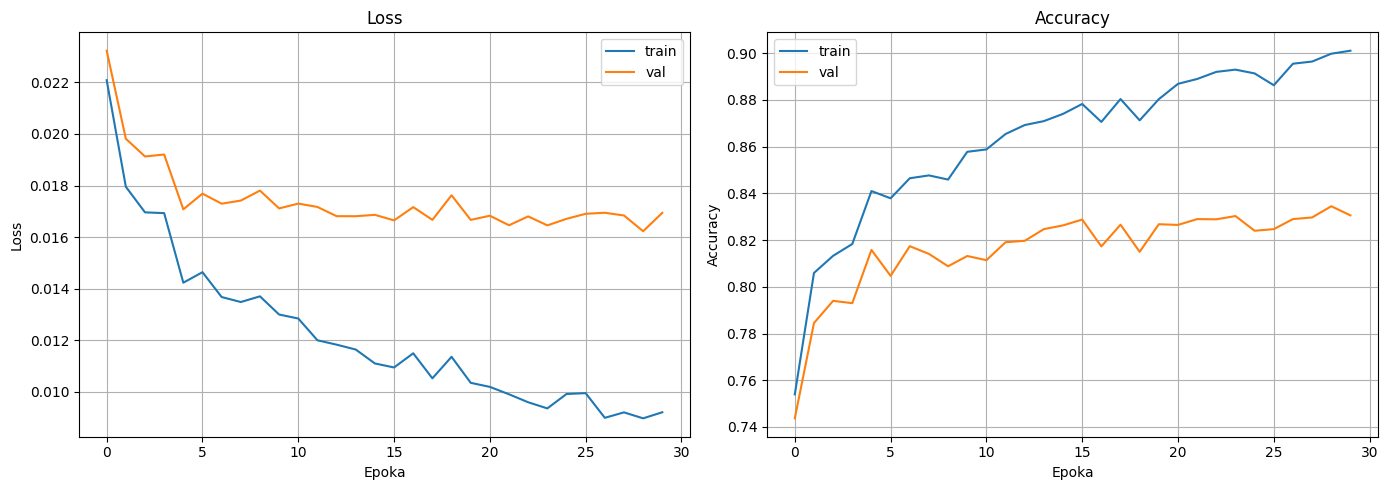

=== WARIANT 2: Fine-tuning ===


/home/mikol/ai_studies/Deep-Neural-Networks-PWR/.venv/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/mikol/ai_studies/Deep-Neural-Networks-PWR/.venv/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG19_Weights.IMAGENET1K_V1`. You can also use `weights=VGG19_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Epoch 0: 100%|██████████| 1563/1563 [00:31<00:00, 48.97it/s]


Epoch 0: train loss = 0.013 (acc: 0.862), val loss = 0.015 (acc: 0.833)


Epoch 1: 100%|██████████| 1563/1563 [00:31<00:00, 50.33it/s]


Epoch 1: train loss = 0.009 (acc: 0.904), val loss = 0.013 (acc: 0.861)


...

Epoch 27: train loss = 0.001 (acc: 0.992), val loss = 0.021 (acc: 0.884)


Epoch 28: 100%|██████████| 1563/1563 [00:30<00:00, 51.81it/s]


Epoch 28: train loss = 0.001 (acc: 0.991), val loss = 0.022 (acc: 0.882)


Epoch 29: 100%|██████████| 1563/1563 [00:30<00:00, 50.74it/s]


Epoch 29: train loss = 0.001 (acc: 0.988), val loss = 0.022 (acc: 0.876)
🏃 View run finetune at: http://localhost:5002/#/experiments/1/runs/35c8defbceee4c3abe19738399b89b2e
🧪 View experiment at: http://localhost:5002/#/experiments/1
Epoka    Train Loss   Train Acc    Val Loss     Val Acc     
--------------------------------------------------------
0        0.0127       0.8619       0.0150       0.8330      
1        0.0089       0.9044       0.0128       0.8607      
2        0.0060       0.9351       0.0118       0.8740      
3        0.0049       0.9490       0.0119       0.8736      
4        0.0031       0.9687       0.0114       0.8837      
5        0.0022       0.9779       0.0125       0.8858      
6        0.0012       0.9900       0.0119       0.8941      
7        0.0010       0.9906       0.0125       0.8895      
8        0.0007       0.9937       0.0131       0.8929      
9        0.0011       0.9885       0.0152       0.8831      
10       0.0006       0.9949       0.01

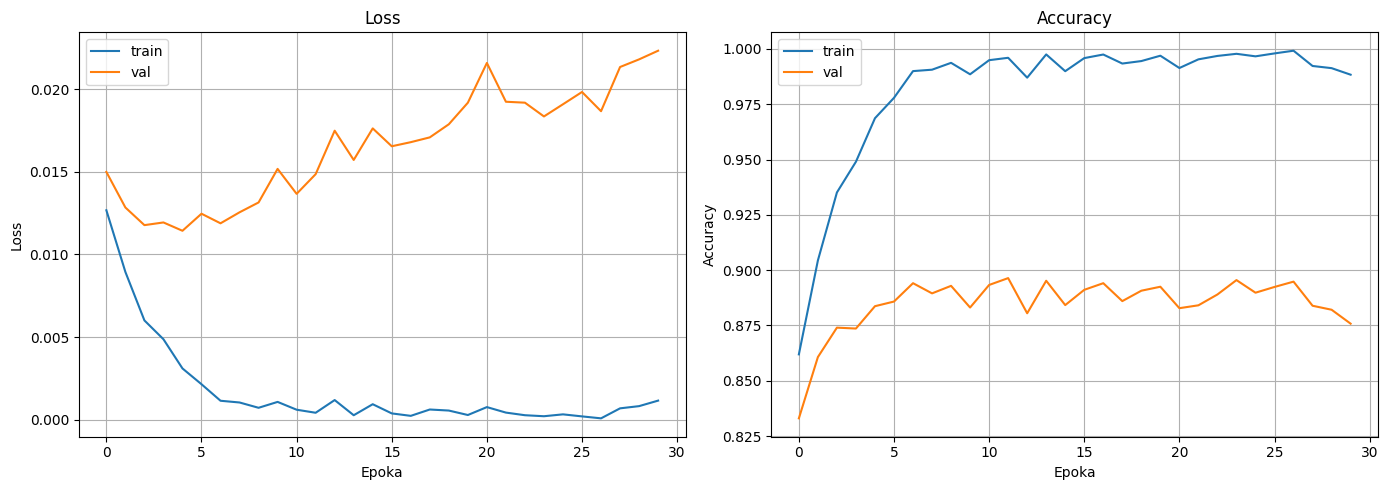

In [7]:
class MultiLevelVGG(nn.Module):
    def __init__(self, n_classes=10, frozen=True, pool_size=(2, 2)):
        super().__init__()
        
        self.backbone = LabVGG19()
        
        for param in self.backbone.parameters():
            param.requires_grad = not frozen
        
        self.pool = nn.AdaptiveAvgPool2d(pool_size)

        flat_size = (64 + 128 + 256) * pool_size[0] * pool_size[1]

        self.classifier = nn.Sequential(
            nn.Linear(flat_size, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, n_classes)
        )
    
    def forward(self, x):
        out0, out1, out2 = self.backbone(x)
        
        f0 = self.pool(out0).flatten(1)
        f1 = self.pool(out1).flatten(1)
        f2 = self.pool(out2).flatten(1)
        
        features = torch.cat([f0, f1, f2], dim=1)
        
        return self.classifier(features)




loss_fn = nn.CrossEntropyLoss()
EPOCHS = 30
# Wariant 1 – zamrożone warstwy konwolucyjne
print("=== WARIANT 1: Zamrożony ===")
model_frozen = MultiLevelVGG(frozen=True).to(device)
optimizer_frozen = optim.Adam(
    filter(lambda p: p.requires_grad, model_frozen.parameters()),
    lr=1e-3
)
history_frozen = fit(
    model_frozen, optimizer_frozen, loss_fn,
    train_dl, test_dl, epochs=EPOCHS,
    run_name="frozen",
    params={"frozen": True, "lr": 1e-3, "epochs": EPOCHS, "pool_size": "2x2"}
)
plot_history(history_frozen)

# Wariant 2 – douczanie warstw konwolucyjnych
print("=== WARIANT 2: Fine-tuning ===")
model_finetune = MultiLevelVGG(frozen=False).to(device)
optimizer_finetune = optim.Adam(model_finetune.parameters(), lr=1e-4)
history_finetune = fit(
    model_finetune, optimizer_finetune, loss_fn,
    train_dl, test_dl, epochs=EPOCHS,
    run_name="finetune",
    params={"frozen": False, "lr": 1e-4, "epochs": EPOCHS, "pool_size": "2x2"}
)
plot_history(history_finetune)

# Zadanie 3

Spróbuj wydobyć cechy za pomocą samodzielmnie wybranego modelu dostępnego w `torchvision.models` (innego niż VGG) a następnie wyuczyć model MLP oparty o cechy na wyjściu konwolucyjnej części całej architektury. Porównaj wynik z tymi, które uzyskała sieć oparta o LabVGG19.

=== RESNET18 WARIANT 1: Zamrożony ===


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /home/mikol/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:12<00:00, 3.62MB/s]
Epoch 0: 100%|██████████| 1563/1563 [00:26<00:00, 60.07it/s]


Epoch 0: train loss = 0.032 (acc: 0.648), val loss = 0.034 (acc: 0.629)


Epoch 1: 100%|██████████| 1563/1563 [00:29<00:00, 53.62it/s]


Epoch 1: train loss = 0.031 (acc: 0.660), val loss = 0.033 (acc: 0.642)


...

Epoch 12: train loss = 0.026 (acc: 0.714), val loss = 0.030 (acc: 0.671)


Epoch 13: 100%|██████████| 1563/1563 [00:27<00:00, 56.17it/s]


Epoch 13: train loss = 0.026 (acc: 0.714), val loss = 0.031 (acc: 0.661)


Epoch 14: 100%|██████████| 1563/1563 [00:28<00:00, 55.61it/s]


Epoch 14: train loss = 0.025 (acc: 0.719), val loss = 0.030 (acc: 0.674)
🏃 View run resnet18_frozen at: http://localhost:5002/#/experiments/1/runs/4fb10574942f47998d65fc36eafb1d80
🧪 View experiment at: http://localhost:5002/#/experiments/1
Epoka    Train Loss   Train Acc    Val Loss     Val Acc     
--------------------------------------------------------
0        0.0322       0.6482       0.0336       0.6291      
1        0.0309       0.6597       0.0330       0.6416      
2        0.0304       0.6654       0.0324       0.6444      
3        0.0289       0.6779       0.0315       0.6537      
4        0.0283       0.6876       0.0314       0.6548      
5        0.0284       0.6874       0.0315       0.6543      
6        0.0288       0.6829       0.0322       0.6457      
7        0.0273       0.6969       0.0310       0.6658      
8        0.0272       0.6954       0.0312       0.6587      
9        0.0268       0.7001       0.0309       0.6624      
10       0.0265       0.7077    

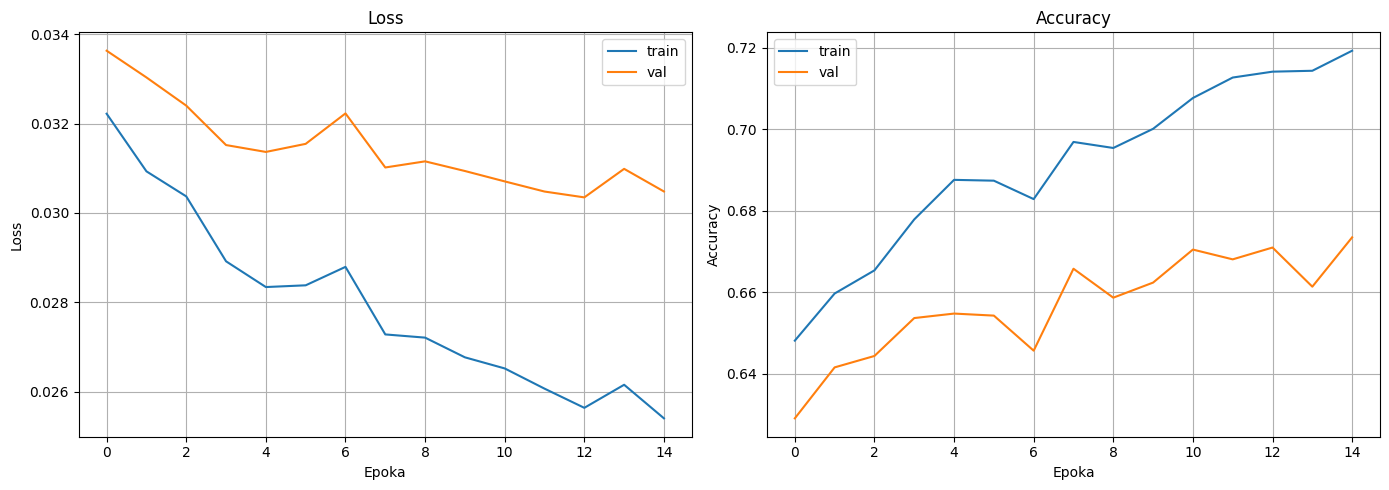

=== RESNET18 WARIANT 2: Fine-tuning ===


Epoch 0: 100%|██████████| 1563/1563 [01:00<00:00, 25.92it/s]


Epoch 0: train loss = 0.007 (acc: 0.933), val loss = 0.011 (acc: 0.882)


Epoch 1: 100%|██████████| 1563/1563 [00:57<00:00, 26.99it/s]


Epoch 1: train loss = 0.004 (acc: 0.965), val loss = 0.010 (acc: 0.893)


...

Epoch 12: train loss = 0.001 (acc: 0.995), val loss = 0.014 (acc: 0.896)


Epoch 13: 100%|██████████| 1563/1563 [05:06<00:00,  5.10it/s] 


Epoch 13: train loss = 0.000 (acc: 0.997), val loss = 0.013 (acc: 0.905)


Epoch 14: 100%|██████████| 1563/1563 [01:00<00:00, 25.97it/s]


Epoch 14: train loss = 0.000 (acc: 0.996), val loss = 0.013 (acc: 0.898)
🏃 View run resnet18_finetune at: http://localhost:5002/#/experiments/1/runs/0b276d6f072043718bed3384bf454445
🧪 View experiment at: http://localhost:5002/#/experiments/1
Epoka    Train Loss   Train Acc    Val Loss     Val Acc     
--------------------------------------------------------
0        0.0067       0.9335       0.0109       0.8823      
1        0.0035       0.9650       0.0103       0.8927      
2        0.0021       0.9789       0.0103       0.8937      
3        0.0012       0.9887       0.0106       0.8984      
4        0.0009       0.9913       0.0111       0.9003      
5        0.0013       0.9864       0.0132       0.8863      
6        0.0006       0.9935       0.0125       0.8961      
7        0.0007       0.9926       0.0131       0.8977      
8        0.0005       0.9946       0.0133       0.8952      
9        0.0005       0.9951       0.0132       0.8983      
10       0.0006       0.9940  

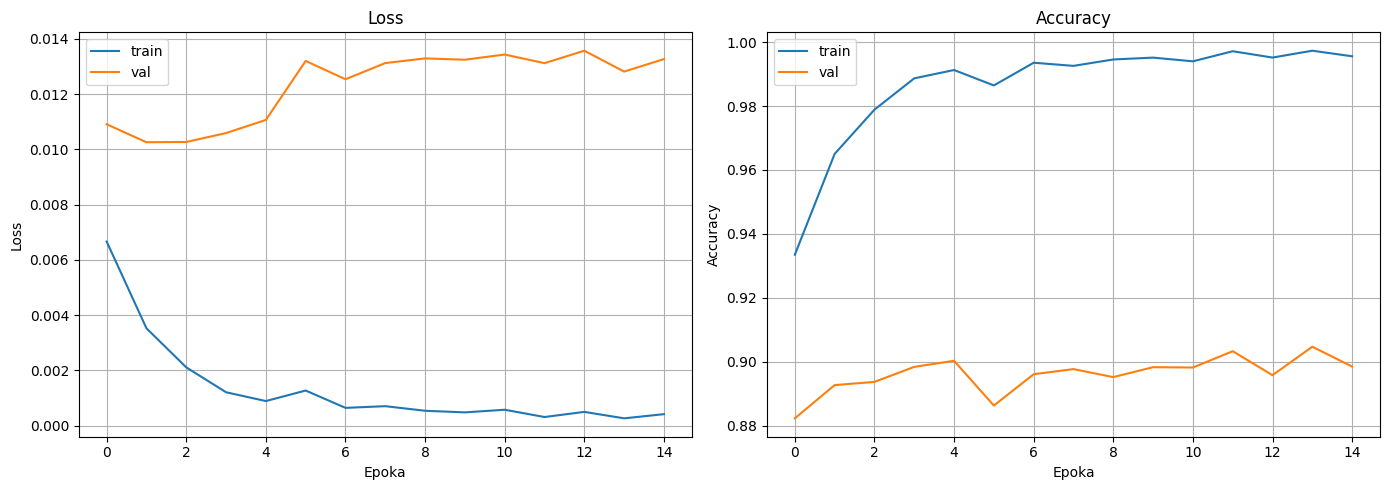

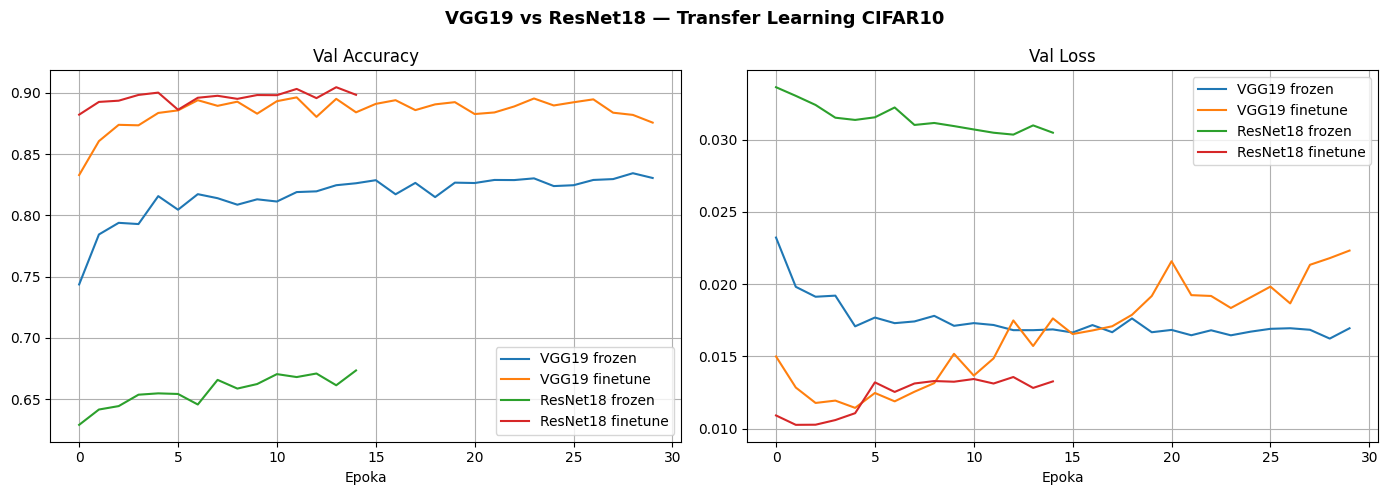


Model                     Best Val Acc
--------------------------------------
VGG19 frozen                    0.8345
VGG19 finetune                  0.8964
ResNet18 frozen                 0.6735
ResNet18 finetune               0.9047


In [10]:
class ResNet18Model(nn.Module):
    def __init__(self, n_classes=10, frozen=True):
        super().__init__()
        
        resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        self.backbone = nn.Sequential(*list(resnet.children())[:-1])
        # wyjście: [B, 512, 1, 1]
        
        for param in self.backbone.parameters():
            param.requires_grad = not frozen
        
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, n_classes)
        )
    
    def forward(self, x):
        x = nn.functional.interpolate(x, size=(64, 64), mode="bilinear", align_corners=False)
        x = self.backbone(x)
        return self.classifier(x)


loss_fn = nn.CrossEntropyLoss()
EPOCHS = 15

# Wariant 1 – zamrożone warstwy konwolucyjne
print("=== RESNET18 WARIANT 1: Zamrożony ===")
model_frozen_rn = ResNet18Model(frozen=True).to(device)
optimizer_frozen_rn = optim.Adam(
    filter(lambda p: p.requires_grad, model_frozen_rn.parameters()),
    lr=1e-3
)
history_frozen_rn = fit(
    model_frozen_rn, optimizer_frozen_rn, loss_fn,
    train_dl, test_dl, epochs=EPOCHS,
    run_name="resnet18_frozen",
    params={"model": "resnet18", "frozen": True, "lr": 1e-3, "epochs": EPOCHS}
)
plot_history(history_frozen_rn)

# Wariant 2 – fine-tuning
print("=== RESNET18 WARIANT 2: Fine-tuning ===")
model_finetune_rn = ResNet18Model(frozen=False).to(device)
optimizer_finetune_rn = optim.Adam(model_finetune_rn.parameters(), lr=1e-4)
history_finetune_rn = fit(
    model_finetune_rn, optimizer_finetune_rn, loss_fn,
    train_dl, test_dl, epochs=EPOCHS,
    run_name="resnet18_finetune",
    params={"model": "resnet18", "frozen": False, "lr": 1e-4, "epochs": EPOCHS}
)
plot_history(history_finetune_rn)

# --- porównanie wszystkich wariantów ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_frozen["val_acc"],       label="VGG19 frozen")
axes[0].plot(history_finetune["val_acc"],     label="VGG19 finetune")
axes[0].plot(history_frozen_rn["val_acc"],    label="ResNet18 frozen")
axes[0].plot(history_finetune_rn["val_acc"],  label="ResNet18 finetune")
axes[0].set_title("Val Accuracy")
axes[0].set_xlabel("Epoka")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history_frozen["val_loss"],      label="VGG19 frozen")
axes[1].plot(history_finetune["val_loss"],    label="VGG19 finetune")
axes[1].plot(history_frozen_rn["val_loss"],   label="ResNet18 frozen")
axes[1].plot(history_finetune_rn["val_loss"], label="ResNet18 finetune")
axes[1].set_title("Val Loss")
axes[1].set_xlabel("Epoka")
axes[1].legend()
axes[1].grid(True)

plt.suptitle("VGG19 vs ResNet18 — Transfer Learning CIFAR10", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# tabelka końcowych wyników
print(f"\n{'Model':<25} {'Best Val Acc':>12}")
print("-" * 38)
print(f"{'VGG19 frozen':<25} {max(history_frozen['val_acc']):>12.4f}")
print(f"{'VGG19 finetune':<25} {max(history_finetune['val_acc']):>12.4f}")
print(f"{'ResNet18 frozen':<25} {max(history_frozen_rn['val_acc']):>12.4f}")
print(f"{'ResNet18 finetune':<25} {max(history_finetune_rn['val_acc']):>12.4f}")

# Transfer stylu

Jedną z ciekawszych demonstracji tego, jak wykorzystać można cechy wyciągane z gotowego modelu jest tzw. transfer stylu - jedno z klasycznych "pokazowych" zastosowań głębokiego uczenia. Tutaj spróbujemy klasycznego podejścia, o wąskiej definicji stylu obejmującej właściwości tekstury obrazu. Obecne metody opierają się raczej o modele dyfuzyjne, w których zarówno zawartość jak i styl są częścią jednej semantycznej przestrzeni reprezentacji (często na podstawie wejścia tekstowego).

Transfer stylu opisany został w roku 2015, w publikacji *A Neural Algorithm of Artistic Style*

https://arxiv.org/abs/1508.06576

To oryginalne, najbardziej klasyczne podejście opiera się optymalizację w przestrzeni obrazu. Parametrem nie jest tutaj sieć, ale właśnie obrazek który próbujemy stworzyć. Dla zadanego obrazka definiującego treść i obrazka definiującego styl skorzystamy z cech zwróconych przez sieć VGG, aby obliczyć dwie funkcje kosztu - koszt treści i stylu. Następnie będziemy optymalizować generowany obraz tak, aby zminimalizować koszt treści względem obrazu określającego pożądaną treść, oraz zminimalizować koszt stylu względem obrazu określającego pożądany styl. Efektem, jeśli wszystko się uda, będzie nowe dzieło, przedstawiające treść obrazka pierwszego *w stylu* obrazka drugiego.

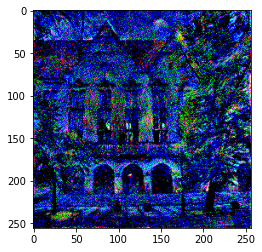

Jak zdefiniować koszt treści? Tutaj rozwiązanie jest proste - błąd średniokwadratowy pomiędzy cechami zwróconymi przez VGG z obrazu docelowego, a tymi zwróconymi z obrazu optymalizowanego. Chcemy żeby nasz obrazek zawierał tę samą treść, a więc oczekujemy, że jego cechy wykrywane przez wyuczony na zadaniu rozpoznawania obiektów model będą podobne.




In [11]:
import torch.nn.functional as F

def content_loss(content_features, input_features):
  return F.mse_loss(content_features, input_features)

Styl/tekstura to trochę bardziej skomplikowane pojęcie. W tym przypadku będziemy o nim myśleć w kategorii rozkładu cech występujących na całej powierzchni obrazu, niezależnie od położenia. Autorzy klasycznego podejścia wybrali jako matematyczny obiekt opisujący ten rozkład macierz Grama:

https://en.wikipedia.org/wiki/Gramian_matrix

Macierz taka jest własnością pewnego zbioru wektorów i aby przybliżyć jej definicję, zamiast korzystać ze wzorów spójrzmy po prostu na implementację:

In [12]:
def calculate_gram_matrices(feature_tensor):
  # zakładamy paczkę map cech na wejściu - a to wymiar batcha
  a,b,c,d = feature_tensor.shape
  reshaped_features = feature_tensor.view(a,b,c*d)
  # wyjście ma wymiar (a,b,b) - jest paczką macierzy
  return torch.matmul(reshaped_features, reshaped_features.transpose(1,2))

Powyższy kod zwraca dla batcha wejściowego, batch macierzy Grama. Możemy myśleć o macierzy Grama jako o obiekcie powiązanym z *macierzą kowariancji* rozkładu cech. Istotne różnice: wektory przy wyliczaniu macierzy Grama nie są przesunięte o średnią, zaś wynik nie jest dzielony przez liczbę punktów, więc nie jest to wartość oczekiwana. To ta druga różnica sprawia, że mówimy o własności *zbioru wektorów* zamiast o własności *rozkładu* - bo elementy macierzy Grama będą zwiększać się z większą liczbą uwzględnionych punktów.
(Naszym zbiorem będzie w tym przypadku *zbiór wszystkich pikseli w danej mapie cech*.) Jeżeli jednak wykorzystujemy obrazy treści i stylu o tym samym rozmiarze co rozmiar obrazu generowanego, ta różnica staje się pomijalna.

Stąd łatwo już przejść do definicji kosztu: kosztem stylu będzie błąd średniokwadratowy pomiędzy macierzami grama opisującymi odpowiednie mapy cech:



In [13]:
def style_loss(style_features, input_features):
  return F.mse_loss(calculate_gram_matrices(style_features), calculate_gram_matrices(input_features))

Pozostaje pytanie, na jakim poziomie wyciągać z architektury cechy? Tutaj jednoznacznej odpowiedzi nie ma, acz typowo stylu szukać będziemy na niższych poziomach, niż treści. W praktyce jednak najlepsze wyniki osiągniemy, próbując dopasować rozwiązanie do konkretnej pary obrazów styl/treść i konkrentej rozdzielczości.

Jescze jedna uwaga na koniec: zauważ, że transfer stylu jest dobrym przykladem zadania gdzie **zawsze** będziemy zamrażać architekturę wydobywającą cechy. Dlaczego? Douczanie ekstraktora cech ułatwiałoby osiągnięcie optimum funkcji kosztu (patrząc na samą wartość). Ale w żaden sposób nie zapewnialibyśmy przy tym, że wydobywane cechy dalej mają coś wspólnego z semantycznymi cechami obrazu. Globalnym optimum w przestrzeni parametrów: obrazu i sieci, byłby ekstraktor który niezależnie od wejścia, zeruje wartości wszystkich cech!

# Zadanie 4

Zaimplementuj transfer stylu, wykorzystując LabVGG19 aby otrzymać cechy na różnych poziomach architektury. Algorytm transferu stylu powinien wykonywać `num_steps` kroków optymalizatora LBFGS, optymalizującego obrazek `input_img` względem kosztów stylu i treści. Koszty stylu i treści powinny być wyliczane na wybieranym parametrem poziomie architektury. Po zakończeniu wyświetl wygenerowany obraz. (Pamiętaj odwróceniu wstępnej operacji normalizacji VGG!)

Przy rozwiązywaniu zadania:

* **nie** modyfikuj funkcji wyliczającej Gram matrix
* zwróć uwagę na różnicę w wartościach poszczególnych kosztów i pamiętaj, że "sensowne" wagi składników kosztu mogą różnić się o kilka rzędów wielkości; postaraj się samemu ustawić je tak, aby osiągnąć wizualnie interesujący wynik
* przetestuj zarówno inicjalizację wartościami losowymi, jak i oryginalnym obrazem treści i zwróć uwagę na różnice wizualne
* możesz dodać składnik kosztu "wygładzający" obrazek (obecny w wielu gotowych implementacjach), ale wtedy porównaj jego wynik z wynikiem gdzie ten składnik jest wyłączony

Pamiętając, że koszty: stylu i treści można wyliczac na różnych poziomach architektury oraz z różnymi wagami, spróbuj dopasować te aspekty algorytmu aby uzyskać interesujący wizualnie efekt.

/home/mikol/ai_studies/Deep-Neural-Networks-PWR/.venv/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG19_Weights.IMAGENET1K_V1`. You can also use `weights=VGG19_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Step  50 | content=20.85 | style=51267.1016 | total=51267120.00
Step 100 | content=21.86 | style=13383.8320 | total=13383854.00
Step 150 | content=22.44 | style=5923.3267 | total=5923349.00
Step 200 | content=22.80 | style=3161.9673 | total=3161990.00
Step 250 | content=23.03 | style=1954.8848 | total=1954907.75
Step 300 | content=23.17 | style=1310.4243 | total=1310447.50
Step 350 | content=23.26 | style=914.7816 | total=914804.88
Step 400 | content=23.41 | style=666.0617 | total=666085.06
Step 450 | content=23.51 | style=502.3472 | total=502370.72
Step 500 | content=23.58 | style=380.7270 | total=380750.59
Step 550 | content=23.65 | style=292.7112 | total=292734.84
Step 600 | content=23.70 | style=228.9372 | total=228960.91


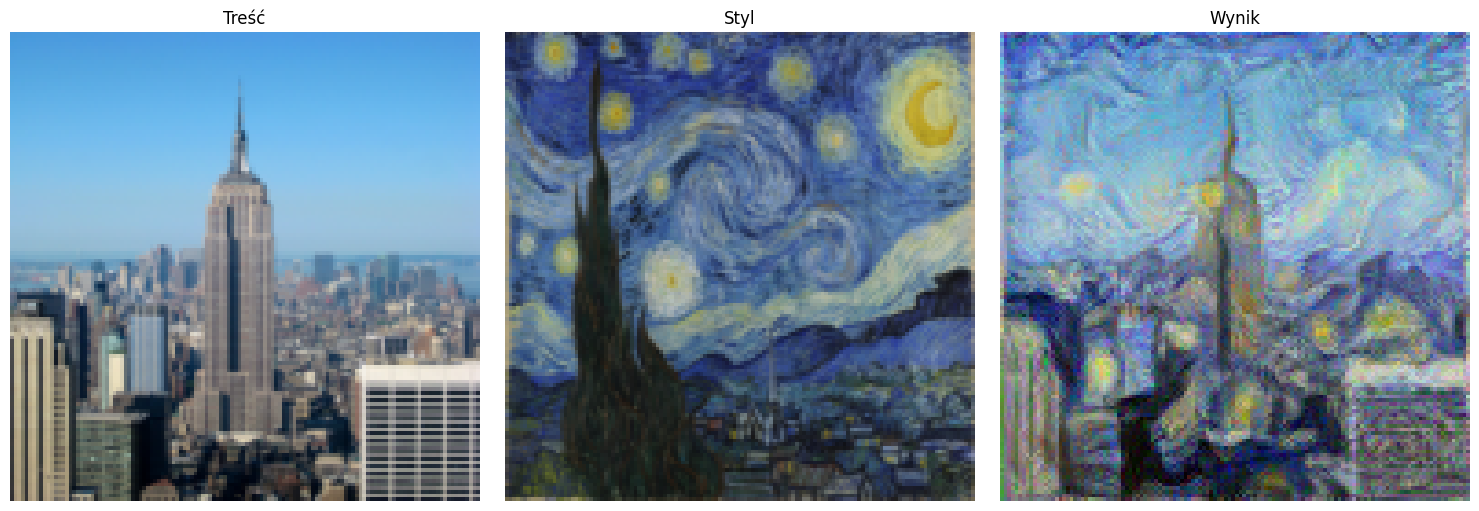

In [14]:
from PIL import Image
import torch
import torchvision.transforms as transforms
import torch.optim as optim
import matplotlib.pyplot as plt

imsize = (128, 128)


def image_loader(image_name):
    image = Image.open(image_name)
    transform = transforms.Compose([
        transforms.Resize(imsize),
        transforms.ToTensor(),
        transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))
    ])
    return transform(image).unsqueeze(0).to(device)

def tensor_to_image(tensor):
    img = tensor.squeeze(0).detach().cpu().clone()
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
    img = img * std + mean
    img = img.clamp(0, 1)
    return img.permute(1, 2, 0).numpy()

# --- wczytaj obrazy ---
style_img   = image_loader("images/styl.jpg")
content_img = image_loader("images/tresc.jpg")

#input_img = torch.randn_like(content_img, requires_grad=True, device=device)
input_img = content_img.clone().requires_grad_(True)

def run_style_transfer(
    content_img, style_img, input_img,
    num_steps=300,
    content_level=2,
    style_level=0,
    content_weight=1,
    style_weight=1e6,
):
    model = LabVGG19().to(device)
    model.eval()

    with torch.no_grad():
        content_features = model(content_img)[content_level]
        style_features   = model(style_img)[style_level]

    optimizer = optim.LBFGS([input_img])

    step = [0]

    while step[0] < num_steps:

        def closure():
            with torch.no_grad():
                input_img.clamp_(-2, 2)

            optimizer.zero_grad()

            input_features = model(input_img)

            c_loss = content_loss(
                content_features,
                input_features[content_level]
            )
            s_loss = style_loss(
                style_features,
                input_features[style_level]
            )

            total_loss = content_weight * c_loss + style_weight * s_loss
            total_loss.backward()

            step[0] += 1
            if step[0] % 50 == 0:
                print(
                    f"Step {step[0]:3d} | "
                    f"content={c_loss.item():.2f} | "
                    f"style={s_loss.item():.4f} | "
                    f"total={total_loss.item():.2f}"
                )

            return total_loss

        optimizer.step(closure)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(tensor_to_image(content_img)); axes[0].set_title("Treść");  axes[0].axis("off")
    axes[1].imshow(tensor_to_image(style_img));   axes[1].set_title("Styl");   axes[1].axis("off")
    axes[2].imshow(tensor_to_image(input_img));   axes[2].set_title("Wynik");  axes[2].axis("off")
    plt.tight_layout()
    plt.show()

    return input_img

result = run_style_transfer(
    content_img, style_img, input_img,
    num_steps=600,
    content_level=2,
    style_level=1,
    content_weight=1,
    style_weight=1e3
)


>>> styl=0, 1e4, init=treść
Step  50 | content=19.64 | style=35648.6406 | total=356486432.00
Step 100 | content=20.82 | style=4959.9395 | total=49599416.00
Step 150 | content=21.76 | style=1111.6541 | total=11116563.00
Step 200 | content=22.08 | style=350.7519 | total=3507540.50
Step 250 | content=22.39 | style=136.2311 | total=1362333.75
Step 300 | content=22.57 | style=64.3863 | total=643885.69


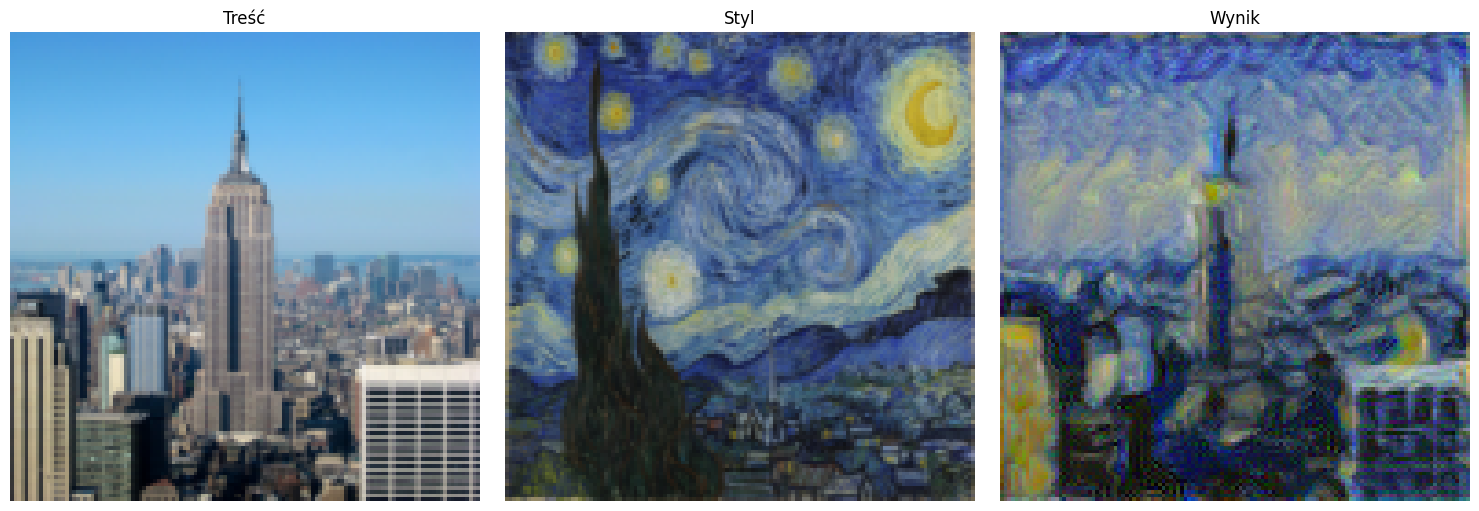


>>> styl=0, 1e4, init=szum
Step  50 | content=34.64 | style=51393.8516 | total=513938560.00
Step 100 | content=34.23 | style=14264.8594 | total=142648624.00
Step 150 | content=33.64 | style=6313.1230 | total=63131264.00
Step 200 | content=33.49 | style=2686.9131 | total=26869164.00
Step 250 | content=33.45 | style=1191.7800 | total=11917833.00
Step 300 | content=33.40 | style=510.7924 | total=5107958.00


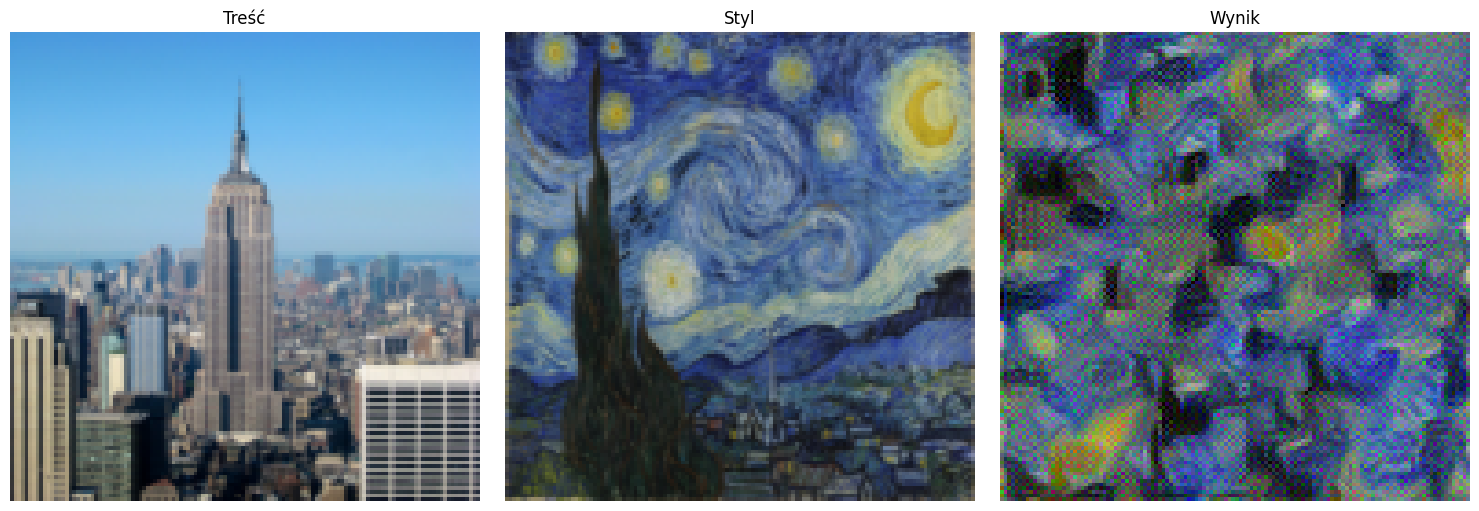


>>> styl=0, 1e6, init=treść
Step  50 | content=19.59 | style=35256.5625 | total=35256561664.00
Step 100 | content=20.89 | style=5530.9360 | total=5530935808.00
Step 150 | content=21.78 | style=1256.1274 | total=1256127488.00
Step 200 | content=22.18 | style=391.0553 | total=391055328.00
Step 250 | content=22.38 | style=150.1591 | total=150159072.00
Step 300 | content=22.49 | style=68.2875 | total=68287512.00


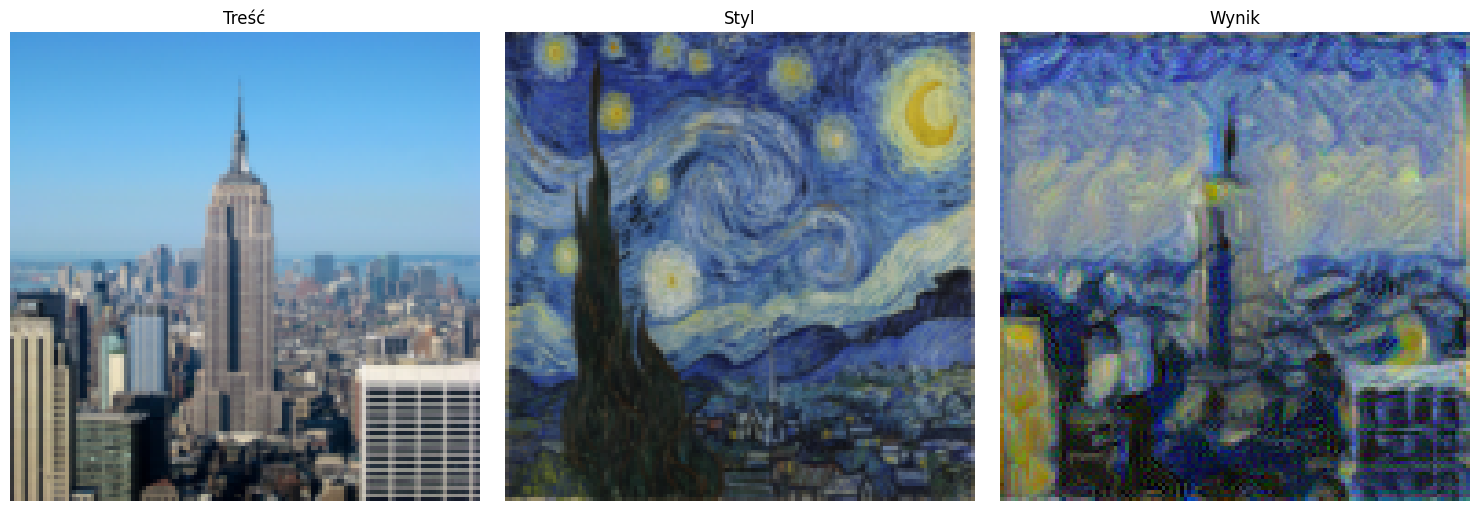


>>> styl=0, 1e6, init=szum
Step  50 | content=33.98 | style=59560.8047 | total=59560804352.00
Step 100 | content=34.03 | style=13934.8047 | total=13934804992.00
Step 150 | content=33.96 | style=6465.9873 | total=6465987072.00
Step 200 | content=33.96 | style=2839.7012 | total=2839701248.00
Step 250 | content=33.96 | style=1215.2157 | total=1215215744.00
Step 300 | content=33.86 | style=543.0743 | total=543074368.00


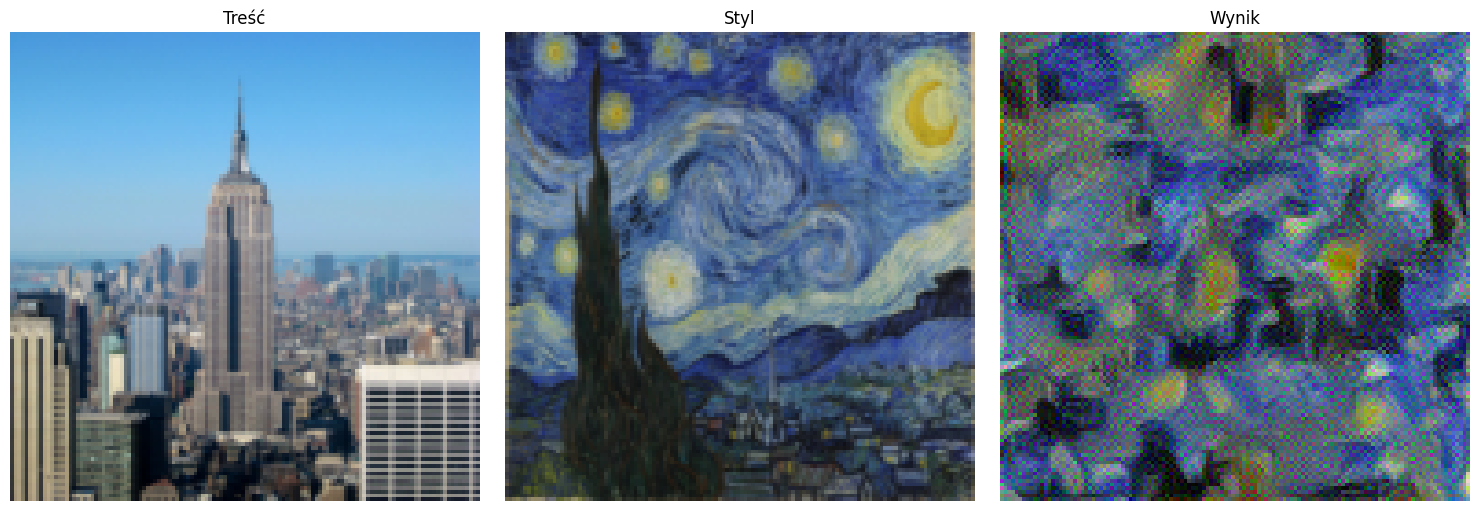


>>> styl=1, 1e4, init=treść
Step  50 | content=20.79 | style=52217.4375 | total=522174400.00
Step 100 | content=21.79 | style=13273.1104 | total=132731128.00
Step 150 | content=22.38 | style=5820.7510 | total=58207532.00
Step 200 | content=22.73 | style=3218.8296 | total=32188318.00
Step 250 | content=22.99 | style=1944.3782 | total=19443804.00
Step 300 | content=23.17 | style=1322.9635 | total=13229658.00


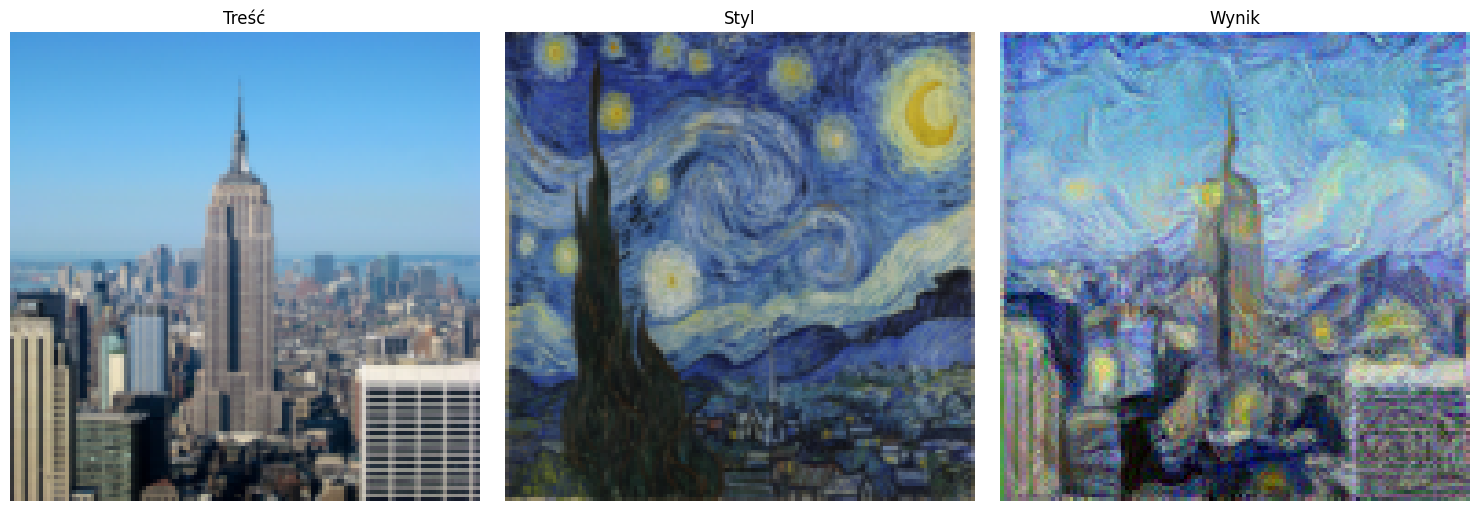


>>> styl=1, 1e4, init=szum
Step  50 | content=31.98 | style=92242.4219 | total=922424192.00
Step 100 | content=32.11 | style=18659.0840 | total=186590864.00
Step 150 | content=32.08 | style=7215.6743 | total=72156776.00
Step 200 | content=31.94 | style=3670.9309 | total=36709340.00
Step 250 | content=31.88 | style=2090.8738 | total=20908770.00
Step 300 | content=31.74 | style=1338.1633 | total=13381665.00


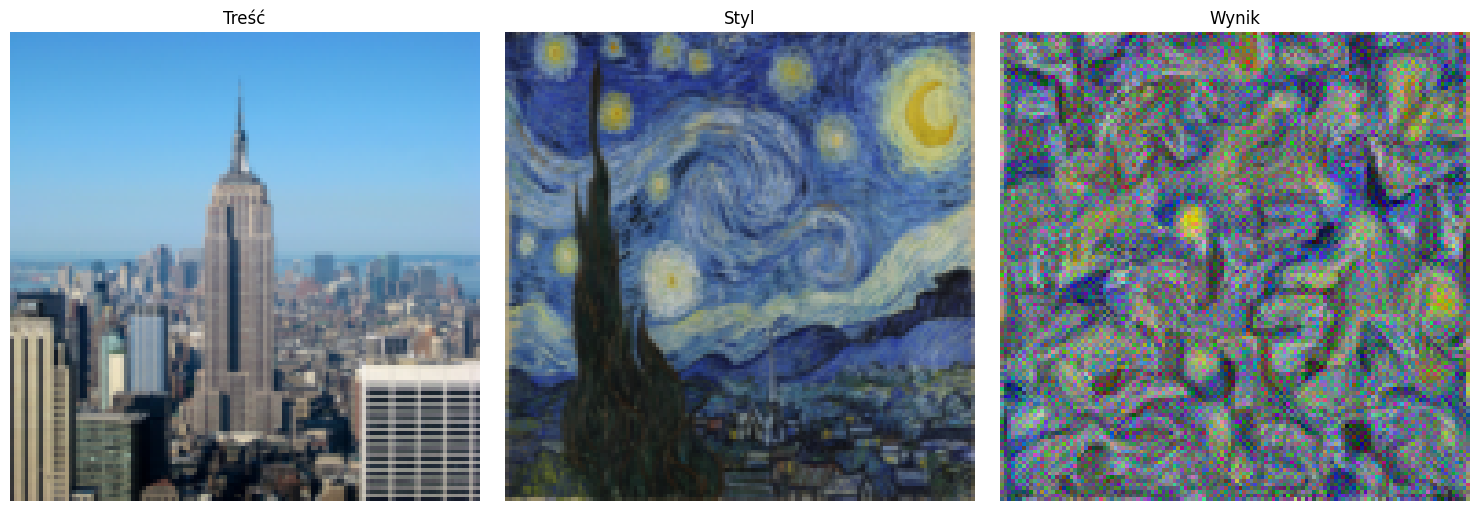

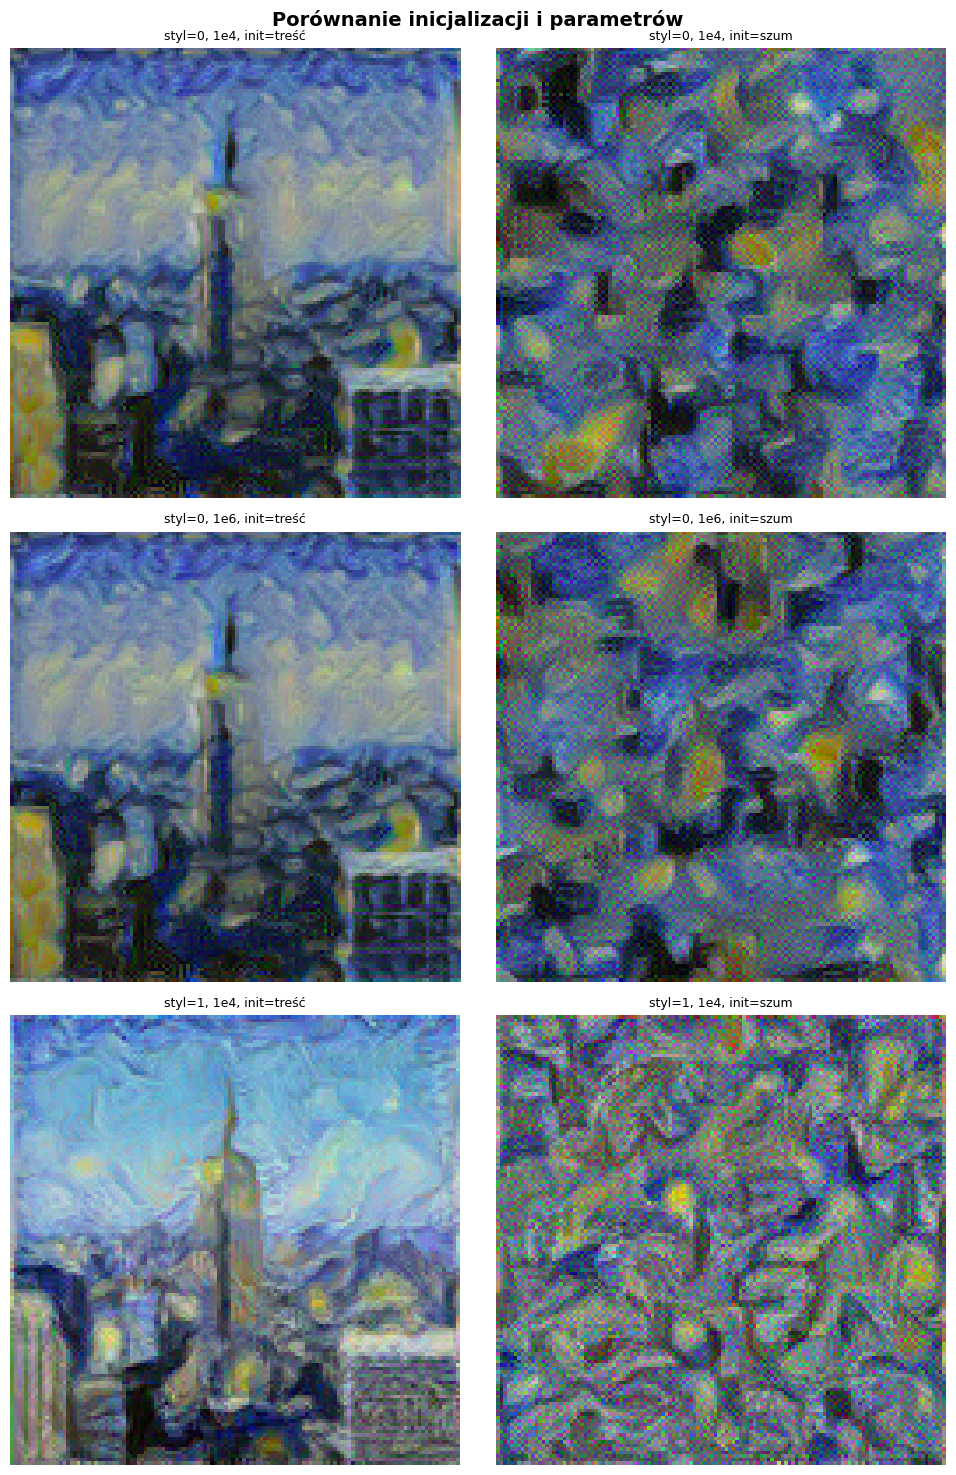

In [15]:
configs = [
    {"content_level": 2, "style_level": 0, "content_weight": 1, "style_weight": 1e4, "init": "content", "label": "styl=0, 1e4, init=treść"},
    {"content_level": 2, "style_level": 0, "content_weight": 1, "style_weight": 1e4, "init": "random",  "label": "styl=0, 1e4, init=szum"},
    {"content_level": 2, "style_level": 0, "content_weight": 1, "style_weight": 1e6, "init": "content", "label": "styl=0, 1e6, init=treść"},
    {"content_level": 2, "style_level": 0, "content_weight": 1, "style_weight": 1e6, "init": "random",  "label": "styl=0, 1e6, init=szum"},
    {"content_level": 2, "style_level": 1, "content_weight": 1, "style_weight": 1e4, "init": "content", "label": "styl=1, 1e4, init=treść"},
    {"content_level": 2, "style_level": 1, "content_weight": 1, "style_weight": 1e4, "init": "random",  "label": "styl=1, 1e4, init=szum"},
]

results = []

for cfg in configs:
    print(f"\n>>> {cfg['label']}")

    # inicjalizacja według parametru
    if cfg["init"] == "random":
        input_img = torch.randn_like(content_img).to(device).requires_grad_(True)
    else:
        input_img = content_img.clone().to(device).requires_grad_(True)

    result = run_style_transfer(
        content_img, style_img, input_img,
        num_steps=300,
        content_level=cfg["content_level"],
        style_level=cfg["style_level"],
        content_weight=cfg["content_weight"],
        style_weight=cfg["style_weight"],
    )
    results.append((cfg["label"], result))

# --- wyświetlanie ---
n = len(results)
cols = 2   # parami: content init vs random init
rows = n // cols

fig, axes = plt.subplots(rows, cols, figsize=(cols * 5, rows * 5))
axes = axes.flatten()

for i, (label, img_tensor) in enumerate(results):
    axes[i].imshow(tensor_to_image(img_tensor))
    axes[i].set_title(label, fontsize=9)
    axes[i].axis("off")

for j in range(len(results), len(axes)):
    axes[j].axis("off")

fig.suptitle("Porównanie inicjalizacji i parametrów", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()